# PaddockTS quickstart

From a bounding box + a date range, this notebook produces:

- segmented paddock polygons (Segment Anything over an NDWI Fourier presegmentation),
- per-paddock time series of every Sentinel-2 band + NDVI / CFI / NIRv / NDTI / CAI,
- pixel-level fractional cover (bare / green / non-green vegetation),
- per-paddock seasonal phenology metrics (SoS / PoS / EoS, amplitudes, integrals),
- co-registered terrain (Copernicus DEM) and OzWALD daily climate,
- diagnostic plots, MP4 timelines, and a stitched PDF report.

All from a single `Query` object and one `get_outputs(query)` call.

> **Runtime.** A ~2 km AOI × 3 months takes 2–5 minutes on a laptop the first run.
> Subsequent runs with the same `Query` are nearly instant — every stage finds its cached output and skips.

## 1. Config

PaddockTS reads config from `~/.config/PaddockTS.json`. Defaults are sensible for a single-user laptop.

The Sentinel-2 chain works without any credentials. The SILO climate stage needs an email; SLGA soils needs a TERN API key. Both gate-keep their respective environmental steps — the rest of the pipeline runs regardless.

In [1]:
from PaddockTS.config import config
print(config)

------------  -------------------------------------------------------------
out_dir       /Users/adeel/borevitz_projects/data/PaddockTSWeb
tmp_dir       /Users/adeel/borevitz_projects/data/PaddockTSWeb
hash_file     /Users/adeel/borevitz_projects/data/PaddockTSWeb/queries.json
email         yasaradeel@gmail.com
tern_api_key  SET
------------  -------------------------------------------------------------


## 2. Build a `Query`

The `Query` is the immutable, content-addressed object every stage consumes. It's described by a bbox in EPSG:4326 (`[west, south, east, north]`), an inclusive start date, an inclusive end date, and an optional `stub` (a short identifier used in every output filename — if omitted, a SHA-256 hash of the inputs is used).

Here we use a ~2 km AOI in southern NSW and a single quarter of 2024 — enough scenes to see the pipeline in action without a long wait.

In [2]:
from datetime import date
from PaddockTS.query import Query

query = Query(
    bbox=[148.36265, -33.52606, 148.38265, -33.50606],   # [W, S, E, N]
    start=date(2024, 1, 1),
    end=date(2024, 3, 31),
    stub="quickstart_demo",
)
print(query)
print("\nOutputs land under :", query.out_dir)
print("Intermediates under :", query.tmp_dir)

-----  --------------------------------------------
stub   quickstart_demo
bbox   [148.36265, -33.52606, 148.38265, -33.50606]
start  2024-01-01
end    2024-03-31
-----  --------------------------------------------

Outputs land under : /Users/adeel/borevitz_projects/data/PaddockTSWeb/quickstart_demo
Intermediates under : /Users/adeel/borevitz_projects/data/PaddockTSWeb/quickstart_demo


## 3. Run the full pipeline

`get_outputs(query)` spawns two worker threads — one for environmental data, one for the Sentinel-2 → PaddockTS chain — and renders a live dashboard until both finish.

Useful flags:

- `reload=True` — wipe every cached artifact for this query and rebuild from scratch.
- `show_log=True` — show a tail-of-log panel under the status tables, handy when a stage looks stuck.
- `paddocks_filepath=...` / `skip_sam=True` — covered in `03_custom_paddocks.ipynb`.

In [ ]:
from PaddockTS.get_outputs import get_outputs

get_outputs(query)

Output()

## 4. List the outputs

By default everything lands under `~/Documents/PaddockTS-Outputs/<stub>/`.

In [ ]:
from pathlib import Path

for p in sorted(Path(query.out_dir).iterdir()):
    size_mb = p.stat().st_size / 1e6 if p.is_file() else 0
    print(f"  {p.name:60s}  {size_mb:>6.2f} MB")

## 5. Open the per-paddock time series

The central data product is the `sam_paddocks_timeseries.zarr` — a `(paddock, time)` cube with one variable per Sentinel-2 band and per spectral index (NDVI, CFI, NIRv, NDTI, CAI). Downstream stages (yearly split, phenology, plots) all consume this.

In [ ]:
import xarray as xr

ts = xr.open_zarr(f"{query.tmp_dir}/sam_paddocks_timeseries.zarr",
                  decode_coords="all")
print(ts)

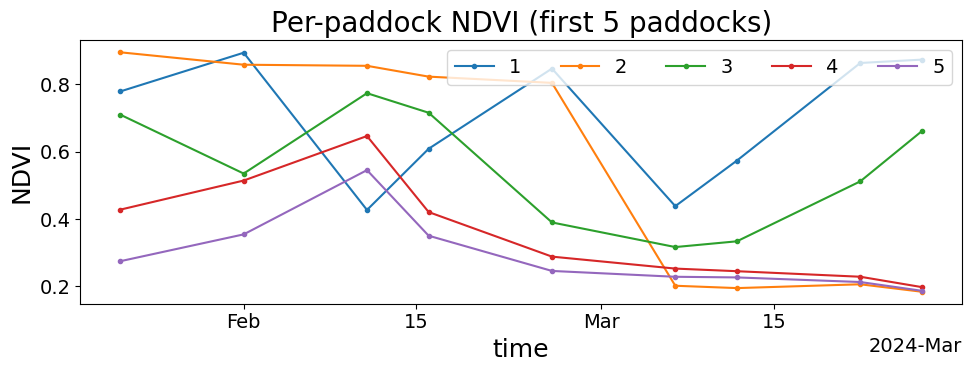

In [30]:
import io
import matplotlib.pyplot as plt
from IPython.display import Image as NBImage, display

# Note: PaddockTS.get_outputs sets matplotlib to the non-interactive 'Agg'
# backend at import time so its worker threads can render headlessly. That
# means Jupyter's inline display protocol isn't hooked into Figure objects —
# `plt.show()` is a no-op and `display(fig)` just prints the figure's repr.
# Workaround: render to a PNG buffer and display the bytes directly.
fig, ax = plt.subplots(figsize=(10, 4))
for p in ts.paddock.values[:5]:
    ts.NDVI.sel(paddock=p).plot(ax=ax, label=str(p), marker=".")
ax.set_title("Per-paddock NDVI (first 5 paddocks)")
ax.set_ylabel("NDVI")
ax.legend(ncol=5, loc="upper right")
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight")
plt.close(fig)
display(NBImage(data=buf.getvalue()))

## 6. Look at one of the visual outputs

The pipeline produces a per-paddock calendar PNG (one per year × page chunk) — rows are paddocks, columns are 48 evenly-spaced slots across the year, each cell is the Sentinel-2 thumbnail of that paddock at the closest observation. Useful for spotting cloud problems, cropping events, or stand-out paddocks at a glance.

In [ ]:
from IPython.display import Image as NBImage, display

cal = next(Path(query.out_dir).glob("*_calendar_*.png"), None)
if cal:
    print(cal.name)
    display(NBImage(filename=str(cal)))
else:
    print("No calendar PNG yet — re-run get_outputs(query).")

## 7. The stitched PDF report

Everything above (topography, climate, satellite calendar, phenology) is combined into a single landscape-A4 PDF at `{query.out_dir}/{query.stub}_report.pdf`. The calendar pages use vector text so labels stay readable at any zoom — see [`02_pipeline_stages.ipynb`](02_pipeline_stages.ipynb) for the details.

In [ ]:
pdf = Path(query.out_dir) / f"{query.stub}_report.pdf"
print("PDF:", pdf, "(exists:", pdf.exists(), ")")

## Where to next

- **[`02_pipeline_stages.ipynb`](02_pipeline_stages.ipynb)** — call each Sentinel-2 stage individually; inspect intermediate outputs.
- **[`03_custom_paddocks.ipynb`](03_custom_paddocks.ipynb)** — use your own paddock boundaries instead of SAM segmentation.
- **[Pipeline reference](https://thestochasticman.github.io/paddock-ts-local/pipeline/)** — full stage-by-stage docs.